# 015. Simple word2vec 작성

- skipgram 방식을 이용하여 window size 2 의 simplified word2vec model 작성  


- embedding layer 의 차원은 2 로 하여 시각화 가능하도록 한다

In [58]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
import numpy as np
import re

### Toy 말뭉치

In [59]:
corpus = ['King is a very strong man.', 
          'Queen is a wise and pretty woman.', 
          'Boy is a young man.',
          'Girl is a young and pretty woman.',
          'Prince is young and will be a strong and wise king.',
          'Princess is a young woman and will be a pretty and wise queen.',
          'Man is strong.', 
          'Woman is pretty.',
          'Prince is a boy will be a king.',
          'Princess is a girl will be a queen.']

# corpus = ['왕은 매우 강한 남자이다', 
#           '여왕은 현명한 예쁜 여자이다', 
#           '소년은 젊은 남자이다',
#           '소녀는 젊은 예쁜 여자이다',
#           '왕자는 젊고 현명한 왕이 될 것이다',
#           '공주는 젊고 예쁜 현명한 여왕이 될 것이다',
#           '남자는 강하다', 
#           '여자는 예쁘다',
#           '왕자는 왕이 될 소년이다',
#           '공주는 왕비가 될 소녀이다']

In [60]:
cleaned_corpus = []
for text in corpus:
    text = re.sub(r'[^a-zA-Z ]', '', text)    #영문
    #text = re.sub(r'[^가-힣 ]', '', text)        # 한글
    cleaned_corpus.append(text.lower())
    
cleaned_corpus

['king is a very strong man',
 'queen is a wise and pretty woman',
 'boy is a young man',
 'girl is a young and pretty woman',
 'prince is young and will be a strong and wise king',
 'princess is a young woman and will be a pretty and wise queen',
 'man is strong',
 'woman is pretty',
 'prince is a boy will be a king',
 'princess is a girl will be a queen']

### stopwords 제거

In [61]:
# # 한글 only
# from konlpy.tag import Okt
# okt = Okt()
# okt.morphs

In [62]:
stop_words = ['is', 'a' ,'will', 'be', 'and']
#stop_words = ['은', '가', '이다', '는', '이', '될']

results = []
    
for text in cleaned_corpus:
    tmp = []
    #for word in okt.morphs(text):  
    for word in text.split():
        if word not in stop_words:
            tmp.append(word)
    results.append(' '.join(tmp))

In [63]:
cleaned_corpus = results
cleaned_corpus

['king very strong man',
 'queen wise pretty woman',
 'boy young man',
 'girl young pretty woman',
 'prince young strong wise king',
 'princess young woman pretty wise queen',
 'man strong',
 'woman pretty',
 'prince boy king',
 'princess girl queen']

### vocaburary 모음 작성

In [64]:
words = []

for sentence in cleaned_corpus:
    for word in sentence.split(' '):
        words.append(word)

words = set(words)
words

{'boy',
 'girl',
 'king',
 'man',
 'pretty',
 'prince',
 'princess',
 'queen',
 'strong',
 'very',
 'wise',
 'woman',
 'young'}

### word-to-index, index-to-word 작성

- word 를 index 로 변환  

- sentence 를 word index 로 변환  

- window size 에 따라 train data 생성

In [65]:
word2index = dict((w, i) for i, w in enumerate(words))
index2word = dict((i, w) for i, w in enumerate(words))

In [66]:
word2index

{'princess': 0,
 'man': 1,
 'queen': 2,
 'boy': 3,
 'pretty': 4,
 'strong': 5,
 'king': 6,
 'wise': 7,
 'girl': 8,
 'woman': 9,
 'prince': 10,
 'very': 11,
 'young': 12}

### skip-gram 으로 training data 생성

In [67]:
sentences = []
for sentence in cleaned_corpus:
    sentences.append(sentence.split())
sentences

[['king', 'very', 'strong', 'man'],
 ['queen', 'wise', 'pretty', 'woman'],
 ['boy', 'young', 'man'],
 ['girl', 'young', 'pretty', 'woman'],
 ['prince', 'young', 'strong', 'wise', 'king'],
 ['princess', 'young', 'woman', 'pretty', 'wise', 'queen'],
 ['man', 'strong'],
 ['woman', 'pretty'],
 ['prince', 'boy', 'king'],
 ['princess', 'girl', 'queen']]

In [68]:
WINDOW_SIZE = 2

data = []
for sentence in sentences:
    for i, word in enumerate(sentence):
        for neighbor in sentence[max(i - WINDOW_SIZE, 0) : min(i + WINDOW_SIZE, len(sentence)) + 1] : 
            if neighbor != word:
                data.append([word, neighbor])

In [69]:
data[:10]

[['king', 'very'],
 ['king', 'strong'],
 ['very', 'king'],
 ['very', 'strong'],
 ['very', 'man'],
 ['strong', 'king'],
 ['strong', 'very'],
 ['strong', 'man'],
 ['man', 'very'],
 ['man', 'strong']]

In [70]:
import pandas as pd

df = pd.DataFrame(data, columns = ['input', 'label'])
df.head()

,input,label
0,king,very
1,king,strong
2,very,king
3,very,strong
4,very,man


### One hot encoding

In [71]:
from tensorflow.keras.utils import to_categorical

len(words)

13

### One hot encoding 된 train, label data

In [72]:
X = [] # input word
Y = [] # target word

for x, y in zip(df['input'], df['label']):
    X.append(to_categorical(word2index[x], len(words)))
    Y.append(to_categorical(word2index[x], len(words)))

In [73]:
X[:3]

[array([0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.], dtype=float32)]

In [74]:
Y[:3]

[array([0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.], dtype=float32)]

In [75]:
# convert them to numpy arrays
X_train = np.array(X)
Y_train = np.array(Y)

**시각화를 위해 hidden layer 의 unit 을 2 로 제한**
- embedding layer : 2

In [76]:
model = Sequential()
model.add(Dense(2, input_dim=len(words)))
model.add(Dense(len(words)))

model.compile(loss="categorical_crossentropy", optimizer='adam', metrics=['accuracy'])

In [77]:
model.fit(X_train, Y_train, epochs=500, batch_size=3)

Train on 84 samples
Epoch 1/500
84/84 [==============================] - 0s 5ms/sample - loss: 5.2560 - accuracy: 0.2381
Epoch 2/500
84/84 [==============================] - 0s 1ms/sample - loss: 5.0840 - accuracy: 0.2381
Epoch 3/500
84/84 [==============================] - 0s 1ms/sample - loss: 4.9523 - accuracy: 0.2381
Epoch 4/500
84/84 [==============================] - 0s 1ms/sample - loss: 5.0330 - accuracy: 0.2381
Epoch 5/500
84/84 [==============================] - 0s 1ms/sample - loss: 4.7491 - accuracy: 0.2857
Epoch 6/500
84/84 [==============================] - 0s 1ms/sample - loss: 4.6181 - accuracy: 0.2857
Epoch 7/500
84/84 [==============================] - 0s 1ms/sample - loss: 5.8354 - accuracy: 0.2857
Epoch 8/500
84/84 [==============================] - 0s 1ms/sample - loss: 6.8589 - accuracy: 0.2857
Epoch 9/500
84/84 [==============================] - 0s 1ms/sample - loss: 6.2050 - accuracy: 0.2857
Epoch 10/500
84/84 [==============================] - 0s 1ms/sample - l

84/84 [==============================] - 0s 988us/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 80/500
84/84 [==============================] - 0s 917us/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 81/500
84/84 [==============================] - 0s 917us/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 82/500
84/84 [==============================] - 0s 905us/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 83/500
84/84 [==============================] - 0s 952us/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 84/500
84/84 [==============================] - 0s 964us/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 85/500
84/84 [==============================] - 0s 1ms/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 86/500
84/84 [==============================] - 0s 940us/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 87/500
84/84 [==============================] - 0s 964us/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 88/500
84/84 [==============================] - 0s 940us/sample - loss: 4

84/84 [==============================] - 0s 917us/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 158/500
84/84 [==============================] - 0s 893us/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 159/500
84/84 [==============================] - 0s 917us/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 160/500
84/84 [==============================] - 0s 952us/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 161/500
84/84 [==============================] - 0s 952us/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 162/500
84/84 [==============================] - 0s 893us/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 163/500
84/84 [==============================] - 0s 952us/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 164/500
84/84 [==============================] - 0s 952us/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 165/500
84/84 [==============================] - 0s 929us/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 166/500
84/84 [==============================] - 0s 929us/sampl

84/84 [==============================] - 0s 1ms/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 236/500
84/84 [==============================] - 0s 1ms/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 237/500
84/84 [==============================] - 0s 940us/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 238/500
84/84 [==============================] - 0s 929us/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 239/500
84/84 [==============================] - 0s 988us/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 240/500
84/84 [==============================] - 0s 1ms/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 241/500
84/84 [==============================] - 0s 917us/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 242/500
84/84 [==============================] - 0s 928us/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 243/500
84/84 [==============================] - 0s 928us/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 244/500
84/84 [==============================] - 0s 917us/sample - lo

84/84 [==============================] - 0s 1ms/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 314/500
84/84 [==============================] - 0s 1ms/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 315/500
84/84 [==============================] - 0s 1ms/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 316/500
84/84 [==============================] - 0s 881us/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 317/500
84/84 [==============================] - 0s 857us/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 318/500
84/84 [==============================] - 0s 857us/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 319/500
84/84 [==============================] - 0s 869us/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 320/500
84/84 [==============================] - 0s 988us/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 321/500
84/84 [==============================] - 0s 905us/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 322/500
84/84 [==============================] - 0s 952us/sample - lo

84/84 [==============================] - 0s 905us/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 391/500
84/84 [==============================] - 0s 1ms/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 392/500
84/84 [==============================] - 0s 1ms/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 393/500
84/84 [==============================] - 0s 1ms/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 394/500
84/84 [==============================] - 0s 976us/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 395/500
84/84 [==============================] - 0s 976us/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 396/500
84/84 [==============================] - 0s 976us/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 397/500
84/84 [==============================] - 0s 952us/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 398/500
84/84 [==============================] - 0s 964us/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 399/500
84/84 [==============================] - 0s 952us/sample - lo

84/84 [==============================] - 0s 929us/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 469/500
84/84 [==============================] - 0s 929us/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 470/500
84/84 [==============================] - 0s 869us/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 471/500
84/84 [==============================] - 0s 1ms/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 472/500
84/84 [==============================] - 0s 1ms/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 473/500
84/84 [==============================] - 0s 1ms/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 474/500
84/84 [==============================] - 0s 964us/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 475/500
84/84 [==============================] - 0s 1ms/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 476/500
84/84 [==============================] - 0s 964us/sample - loss: 4.4133 - accuracy: 0.2857
Epoch 477/500
84/84 [==============================] - 0s 1ms/sample - loss: 

### 첫번째 Hidden Layer 추출 및 weight + bias 를 vector 로 합산

In [78]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_4 (Dense)              (None, 2)                 28        
_________________________________________________________________
dense_5 (Dense)              (None, 13)                39        
Total params: 67
Trainable params: 67
Non-trainable params: 0
_________________________________________________________________


In [79]:
model.layers[0].get_weights()

[array([[ 0.12764427, -0.14171596],
        [-0.28452086,  0.59177333],
        [ 0.17253059, -0.32999828],
        [ 0.45327505,  0.63959056],
        [ 0.3919075 , -0.12385505],
        [ 0.51376516,  0.06437788],
        [ 0.50734264,  0.11308521],
        [ 0.30121166, -0.26154578],
        [ 0.02934275, -0.21888568],
        [-0.30650836, -0.38953617],
        [-0.10748327,  0.4267351 ],
        [ 0.55825096,  0.03070444],
        [ 0.30311835,  0.04408614]], dtype=float32),
 array([ 0.02832843, -0.08901755], dtype=float32)]

In [80]:
vectors= model.layers[0].get_weights()[0]

In [81]:
w2v = pd.DataFrame(vectors, columns = ['x1', 'x2'])
w2v['word'] = words
w2v

,x1,x2,word
0,0.127644,-0.141716,princess
1,-0.284521,0.591773,man
2,0.172531,-0.329998,queen
3,0.453275,0.639591,boy
4,0.391908,-0.123855,pretty
5,0.513765,0.064378,strong
6,0.507343,0.113085,king
7,0.301212,-0.261546,wise
8,0.029343,-0.218886,girl
9,-0.306508,-0.389536,woman


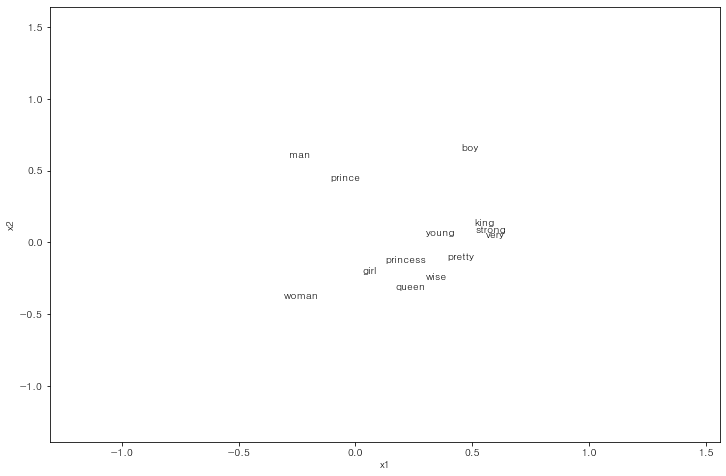

In [82]:
import matplotlib.pyplot as plt
%matplotlib inline
#한글 폰트 사용
from matplotlib import font_manager
import matplotlib
font_path = "C:/Windows/Fonts/H2GTRM.TTF"                       #폰트 경로
font_name = font_manager.FontProperties(fname=font_path).get_name()  #폰트 이름 얻어오기
matplotlib.rc('font', family=font_name)                                 #font 지정
matplotlib.rcParams['axes.unicode_minus'] = False               #한글사용시 마이너스 사인 깨짐 방지

fig, ax = plt.subplots(figsize=(12,8))

for word, x1, x2 in zip(w2v['word'], w2v['x1'], w2v['x2']):
    ax.annotate(word, (x1, x2))
    
PADDING = 1.0
x_axis_min = np.min(vectors, axis=0)[0] - PADDING
y_axis_min = np.min(vectors, axis=0)[1] - PADDING
x_axis_max = np.max(vectors, axis=0)[0] + PADDING
y_axis_max = np.max(vectors, axis=0)[1] + PADDING
 
plt.xlim(x_axis_min, x_axis_max)
plt.ylim(y_axis_min, y_axis_max)
plt.xlabel('x1')
plt.ylabel('x2')

plt.show()

## Embedding Projector 와 비교

https://projector.tensorflow.org/ 